# Synthetic test: build a river profile, then invert it

A single end-to-end example. We prescribe a flat-ramp-flat thrust, generate the
steady-state river profile it would produce under the stream-power law, add
noise, and then recover the fault geometry and the stream-power exponents from
that profile alone.

Runtime is about ninety seconds.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import emcee, multiprocessing as mp
import thrust_fault_model as tf, run_inversion as ri

SLIP = 1.0          # slip rate, normalised (uplift is reported per unit slip)
X_END = 200.0       # section length from the MFT, km
rng = np.random.default_rng(0)

## 1. Truth fault

Ten control points tracing a 5 deg frontal flat, a 15 deg ramp between 100 and
140 km, and a 5 deg deep flat. `w` is the smoothing half-width at each interior
hinge, non-zero only at the two real dip changes.

In [2]:
def flat_ramp_flat(x, x_lo=100.0, x_hi=140.0, d_front=5.0, d_ramp=15.0, d_deep=5.0):
    """Depth of a flat-ramp-flat fault at each x, integrating dip downdip."""
    z, x = [0.0], np.asarray(x, float)
    for x0, x1 in zip(x[:-1], x[1:]):
        dip = d_front if x0 < x_lo else (d_ramp if x0 < x_hi else d_deep)
        z.append(z[-1] - (x1 - x0) * np.tan(np.radians(dip)))
    return np.array(z)

x_true = np.array([0, 25, 50, 75, 100, 115, 130, 140, 170, 200], float)
z_true = flat_ramp_flat(x_true)
w_true = np.array([0, 0, 0, 5, 0, 0, 5, 0], float)   # one per interior hinge

x_master = np.linspace(1e-1, X_END, 1000)
uplift_true, (xn_true, zn_true) = ri.compute_uplift_from_fault_varw(
    x_true, z_true, w_true, x_master=x_master, structuralslip=SLIP,
    n_dense=600, n_nodes=350)

## 2. Forward model

Fault-bend folding gives the rock-uplift field `U(x)`. At steady state
`U = K A^m |dz/dx|^n`, so the profile follows from integrating
`|dz/dx| = (U/K)^(1/n) A^(-m/n)` upstream from the outlet. Drainage area comes
from Hack's law. `K` is set to put the headwaters at 6.5 km.

In [3]:
M_TRUE, N_TRUE, NOISE_M = 0.5, 2.0, 50.0

sim_y = np.linspace(0.0, X_END, 1000)       # distance from outlet at the MFT, km
csv = "synthetic_river.csv"
pd.DataFrame({"sim_x": np.zeros_like(sim_y), "sim_y": sim_y,
              "elevation": np.zeros_like(sim_y)}).to_csv(csv, index=False)

data = tf.load_channel_profile_csv(csv, uplift_sample_axis="sim_y",
                                   use_length_weights=True,
                                   hack_exp=ri.COMMON["hack_exp"],
                                   l0_m=ri.COMMON["l0_m"])

U_chan = tf.interp_linear_extrap(data.x_uplift_coord_order, x_master, uplift_true)
I = tf.stream_power_integral_I_from_uplift(U_chan, data.ds_m, data.A_mid,
                                           m_sp=M_TRUE, n_sp=N_TRUE)

K_TRUE = (I[-1] / 6500.0) ** N_TRUE          # fix K by the target peak elevation
z_clean = K_TRUE ** (-1.0 / N_TRUE) * I
z_obs = z_clean + rng.normal(0.0, NOISE_M, z_clean.shape)

pd.DataFrame({"sim_x": np.zeros_like(sim_y), "sim_y": sim_y,
              "elevation": z_obs}).to_csv(csv, index=False)
data = tf.load_channel_profile_csv(csv, uplift_sample_axis="sim_y",
                                   use_length_weights=True,
                                   hack_exp=ri.COMMON["hack_exp"],
                                   l0_m=ri.COMMON["l0_m"])   # reload with elevations
print(f"K_true = {K_TRUE:.3e}, peak = {z_clean.max():.0f} m")

K_true = 9.211e-06, peak = 6500 m


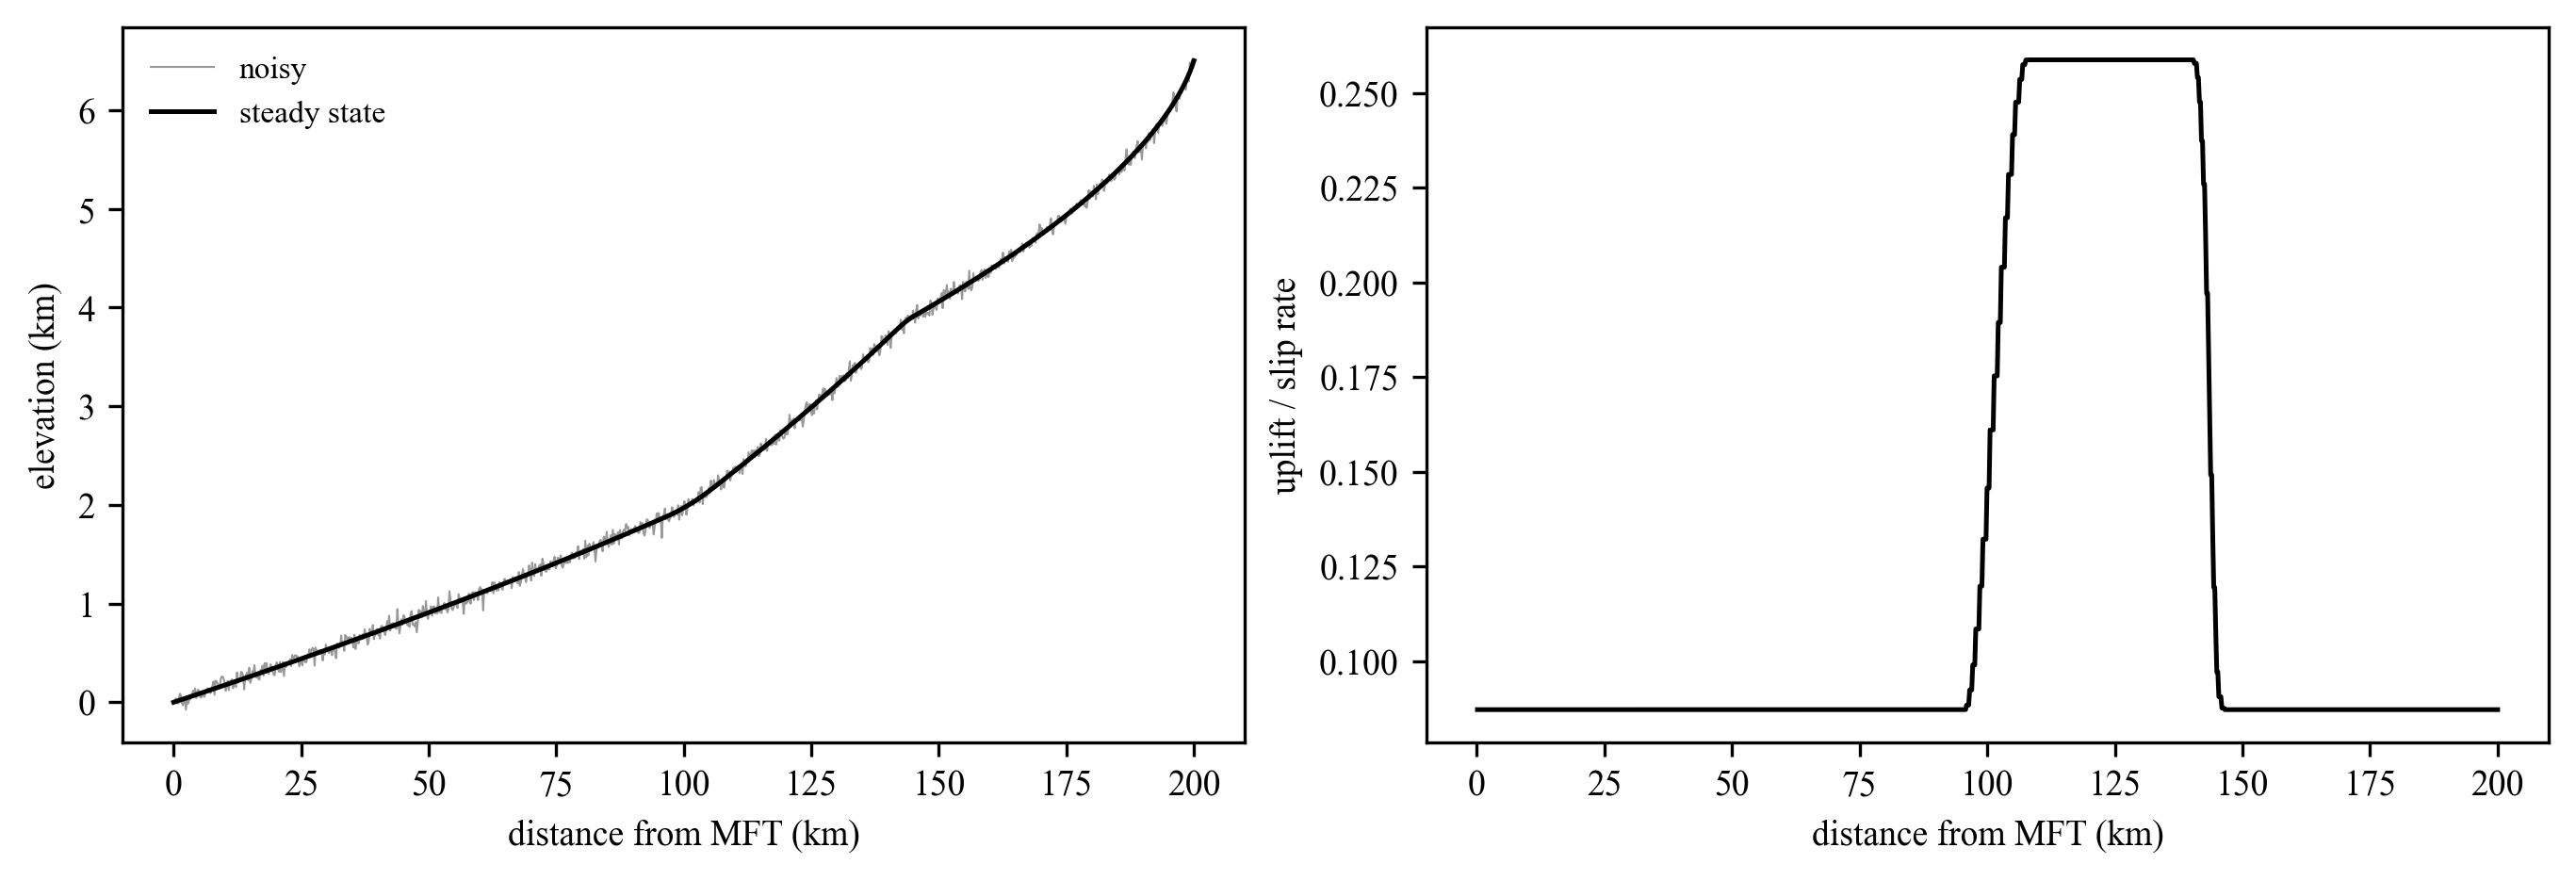

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
ax[0].plot(sim_y, z_obs / 1e3, lw=0.5, color="0.6", label="noisy")
ax[0].plot(sim_y, z_clean / 1e3, "k", lw=1.2, label="steady state")
ax[0].set(xlabel="distance from MFT (km)", ylabel="elevation (km)")
ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(x_master, uplift_true, "k", lw=1.2)
ax[1].set(xlabel="distance from MFT (km)", ylabel="uplift / slip rate")
plt.show()

## 3. Invert

Config `F3` samples the ten fault control points, the hinge smoothing widths,
and both stream-power exponents `m` and `n`. Nothing about the ramp is imposed
— walkers start from a planar 7 deg fault, so a ramp has to be found in the
data. Chain length here is short enough to run interactively.

In [5]:
fault_cfg, post = ri.make_posterior("F3", data=data, x_master=x_master,
                                    structuralslip=SLIP)
nwalkers, nsteps, burn, thin = 80, 6000, 4000, 10
p0 = post.draw_initial_ball(np.random.default_rng(42), nwalkers, planar_dip_deg=7.0)

with mp.get_context("fork").Pool(max(1, mp.cpu_count() - 1)) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, post.ndim, post, pool=pool)
    sampler.run_mcmc(p0, nsteps, progress=True)

chain = sampler.get_chain(discard=burn, thin=thin, flat=True)
print(f"ndim = {post.ndim}, samples = {len(chain)}")

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 5/6000 [00:00<02:02, 48.86it/s]

  0%|          | 11/6000 [00:00<01:51, 53.79it/s]

  0%|          | 17/6000 [00:00<01:46, 55.92it/s]

  0%|          | 24/6000 [00:00<01:41, 58.80it/s]

...

100%|█████████▉| 5978/6000 [01:22<00:00, 73.90it/s]

100%|█████████▉| 5986/6000 [01:22<00:00, 73.43it/s]

100%|█████████▉| 5994/6000 [01:22<00:00, 73.07it/s]

100%|██████████| 6000/6000 [01:22<00:00, 72.81it/s]

ndim = 27, samples = 16000


## 4. Compare with truth

Evaluate a posterior subsample. Ramp position and dip are measured on each
sample and then summarised, which is what `run_inversion.py` does.

In [6]:
xn, zn, zp, m_s, n_s, rx, rd = [], [], [], [], [], [], []
for th in chain[np.random.default_rng(0).choice(len(chain), 200)]:
    out = post.evaluate(th, n_dense=600, n_nodes=350)
    if out is None:
        continue
    xn.append(out["xnode"]); zn.append(out["znode"]); zp.append(out["z_pred"])
    cx, dd = ri.ramp_center_and_dip(out["xnode"], out["znode"])
    rx.append(cx); rd.append(dd)
    _, m_i, n_i, _ = post._split(th)
    m_s.append(m_i); n_s.append(n_i)

xn_med, zn_med = np.median(xn, 0), np.median(zn, 0)
rx_t, rd_t = ri.ramp_center_and_dip(xn_true, zn_true)

for name, truth, samp in [("m", M_TRUE, m_s), ("n", N_TRUE, n_s),
                          ("ramp x (km)", rx_t, rx), ("ramp dip (deg)", rd_t, rd)]:
    print(f"{name:>14}   truth {truth:6.2f}   recovered {np.median(samp):6.2f}")

             m   truth   0.50   recovered   0.64
             n   truth   2.00   recovered   2.20
   ramp x (km)   truth 119.89   recovered 112.30
ramp dip (deg)   truth  15.00   recovered  18.16


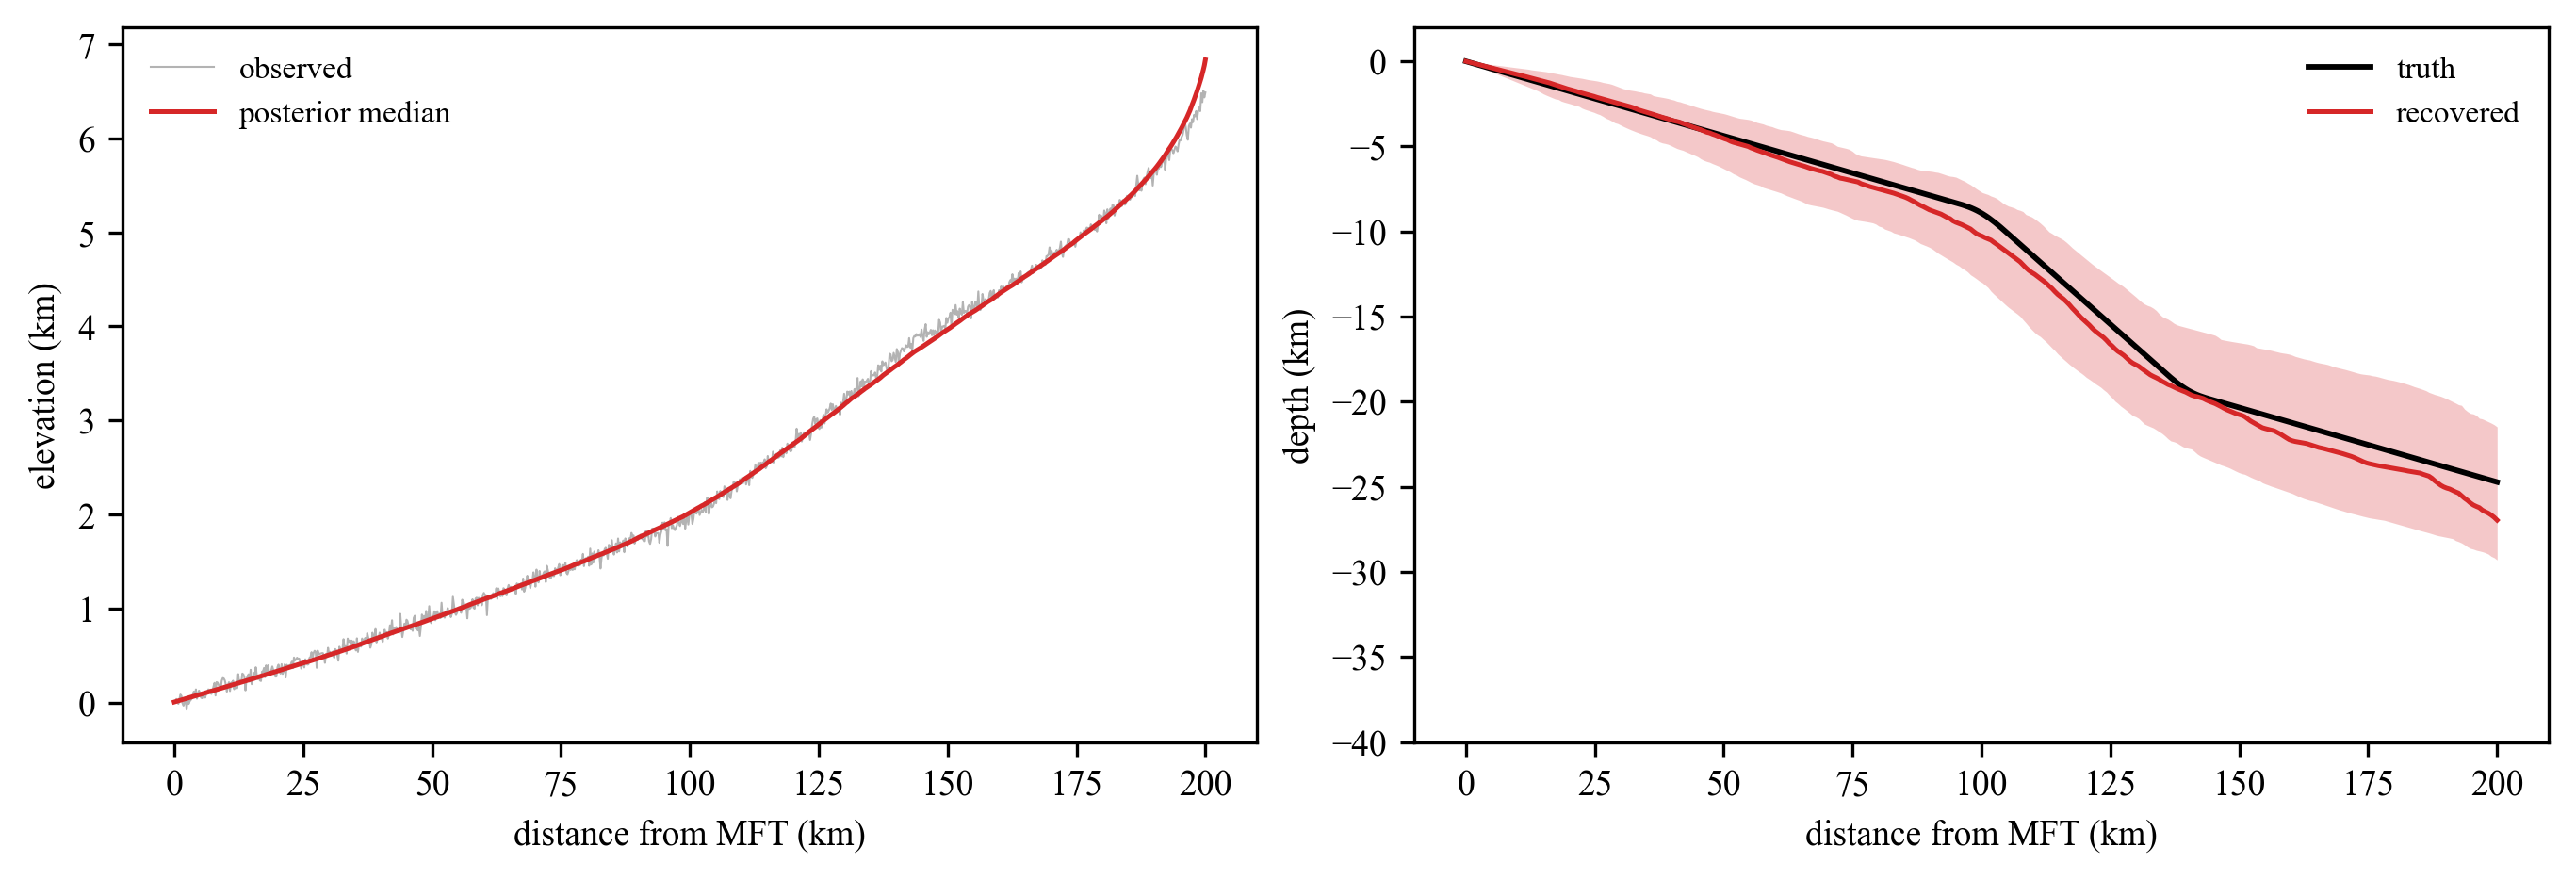

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
ax[0].plot(sim_y, z_obs / 1e3, lw=0.5, color="0.7", label="observed")
ax[0].plot(data.s_km_model, np.median(zp, 0) / 1e3, "C3", lw=1.2, label="posterior median")
ax[0].set(xlabel="distance from MFT (km)", ylabel="elevation (km)")
ax[0].legend(frameon=False, fontsize=8)

ax[1].fill_between(xn_med, np.percentile(zn, 16, 0), np.percentile(zn, 84, 0),
                   color="C3", alpha=0.25, lw=0)
ax[1].plot(xn_true, zn_true, "k", lw=1.4, label="truth")
ax[1].plot(xn_med, zn_med, "C3", lw=1.2, label="recovered")
ax[1].set(xlabel="distance from MFT (km)", ylabel="depth (km)", ylim=(-40, 2))
ax[1].legend(frameon=False, fontsize=8)
plt.show()

The ramp is located to within about 8 km and 3 degrees from the profile alone,
with no prior on where it sits. `m` and `n` come out biased high and trade off
against each other, the usual stream-power degeneracy — a longer chain and a
denser profile tighten both.

For real rivers, replace step 2 with a profile extracted by `snap_rivers.py` and
run `run_inversion.py --seg N --config F3`.